## **Credit Fraud Analysis - EDA**

Trong lĩnh vực tài chính số, phát hiện gian lận giao dịch là một nhiệm vụ quan trọng nhằm giảm thiểu tổn thất và nâng cao tính an toàn của hệ thống. Notebook này tập trung phân tích bộ dữ liệu giao dịch tài chính để khám phá đặc điểm dữ liệu và xây dựng nền tảng cho bài toán fraud detection.

**Mục tiêu:**

1. **Exploratory Data Analysis (EDA):** Khám phá đặc điểm thống kê, phân phối dữ liệu và cấu trúc các biến.
2. **Data Quality Check:** Kiểm tra dữ liệu thiếu, dữ liệu trùng lặp và các giá trị bất thường.
3. **Feature Relationship Analysis:** Phân tích mối quan hệ giữa các biến đầu vào với biến mục tiêu `isFraud`.
4. **Modeling Preparation:** Chuẩn bị cơ sở cho bước tiền xử lý và xây dựng mô hình machine learning.

### **1. Nhập dữ liệu và thư viện**


In [28]:
# Import thư viện xử lý dữ liệu 
import numpy as np
import pandas as pd 
from pathlib import Path
# Import thư viện trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker


In [29]:
# Nhập dữ liệu thông qua đường dẫn tương đối
path = Path('data') / 'AIML Dataset.csv'
data = pd.read_csv(path)

### **2. Kiểm tra và làm sạch dữ liệu**
 

#### **2.1. Mô tả dữ liệu**

In [30]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [32]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Từ phân tích ta có thể thấy: 
- Bộ dữ liệu lớn, có **~6.3 triệu quan sát**
- Step là biến khung thời gian (theo giờ), không nên dùng làm feature, mà nên dùng để **aggregate dữ liệu** để tạo feature mới.
- Các biến amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest đều có **dấu hiệu lệch phải (right skew)** (mean >> median).
- Type có thể dùng làm feature, nhưng hiện đang ở dạng object (cần **hot encode** trước khi đưa vào mô hình).


#### **2.2. Kiểm tra và xử lý dữ liệu thiếu (missing values)**

In [33]:
data.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

-> Không có giá trị trống (missing values) trong các cột của bộ dữ liệu

#### **2.3. Kiểm tra và xử lý dữ liệu trùng lặp (duplicates)**

In [34]:
data.duplicated().sum()

np.int64(0)

-> Bộ dữ liệu không có hàng trùng lặp

-----

### **3. Phân tích đơn, đa biến (Univariate + Multivariate analysis)**

#### **3.1. Phân tích biến mục tiêu (isFraud)**

Kiểm tra class balance:

[]

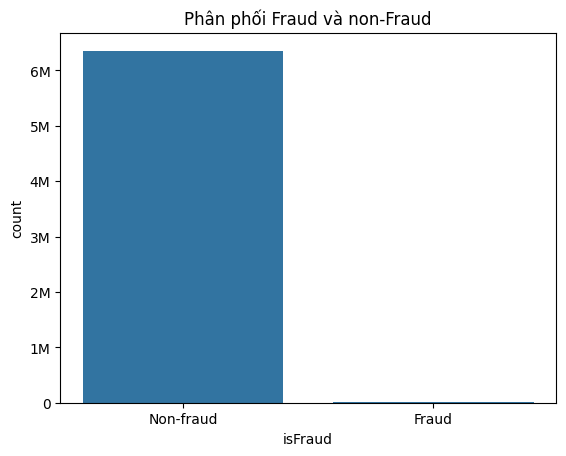

In [35]:
sns.countplot(data = data, x = 'isFraud')
plt.title('Phân phối Fraud và non-Fraud')
plt.xticks([0,1], ['Non-fraud', 'Fraud'])
plt.gca().yaxis.set_major_formatter(mticker.EngFormatter(sep =''))
plt.plot()

In [36]:
data['isFraud'].value_counts(normalize = True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

Biến isFraud **mất cân bằng nghiêm trọng** (chỉ **~0.13%** số quan sát là Fraud). Điều này phản ánh đúng dữ liệu credit fraud, nhưng cần có sự can thiệp trước khi đưa vào mô hình học máy. 

=> **Resample** sẽ được thực hiện trên tệp **train** sau bước train test split.



#### **3.2. Phân tích các mối quan hệ giữa các biến**

##### 📊Kiểm tra phân phối của biến **amount**: 

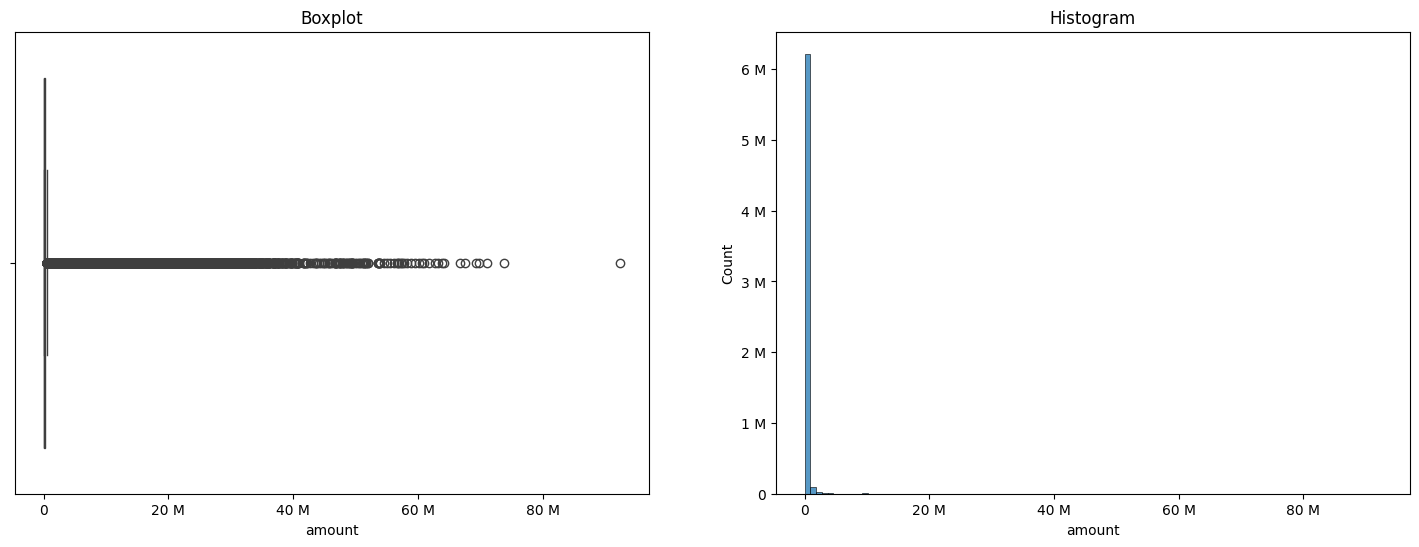

In [37]:
fig, ax = plt.subplots(1,2, figsize = (18,6))
sns.boxplot(data = data, x = 'amount', ax = ax[0])
ax[0].set_title('Boxplot')
ax[0].xaxis.set_major_formatter(mticker.EngFormatter())
sns.histplot( data = data, x = 'amount', bins = 100, ax = ax[1])
ax[1].set_title('Histogram')
ax[1].xaxis.set_major_formatter(mticker.EngFormatter())
ax[1].yaxis.set_major_formatter(mticker.EngFormatter())

plt.show()

Có thể thấy: 
- Biến amount bị **lệch phải nghiêm trọng**, với một nhóm lớn quan sát tập trung gần 0. 
- Có **nhiều outliers**, có những outliers giá trị lên đến 90M.

##### 📊Kiểm tra phân phối của biến **amount** dạng logged.

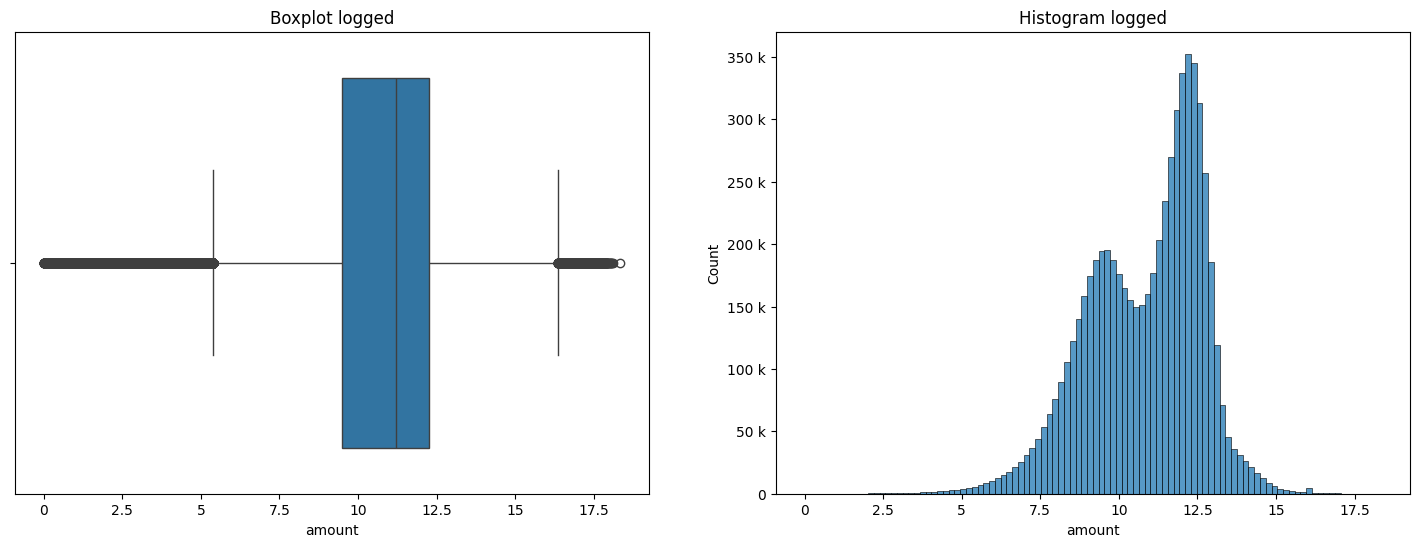

In [38]:
fig, ax = plt.subplots(1,2, figsize = (18,6))
sns.boxplot(x = np.log1p(data['amount']), ax = ax[0])
ax[0].set_title('Boxplot logged')
ax[0].xaxis.set_major_formatter(mticker.EngFormatter())
sns.histplot( x = np.log1p(data['amount']), bins = 100, ax = ax[1])
ax[1].set_title('Histogram logged')
ax[1].xaxis.set_major_formatter(mticker.EngFormatter())
ax[1].yaxis.set_major_formatter(mticker.EngFormatter())

plt.show()

Sau khi log, ta có thể thấy: 
- Phân phối của biến đối xứng hơn, có thể giúp tăng tính ổn định khi đưa vào mô hình ML.
- Phân phối trong histogram gợi ý sự tồn tại của **2 nhóm** chính, có thể có mối quan hệ với biên isFraud.

Tuy nhiên, do các mô hình không giả đính tính đối xứng của các features nên ta sẽ **không xây dựng feature log(amount)**

##### 📊**Phân tích: Sự khác biệt về lượng giao dịch (amount) giữa nhóm Fraud và nhóm Non-fraud**

Text(0.5, 1.0, 'Amount theo trạng thái fraud')

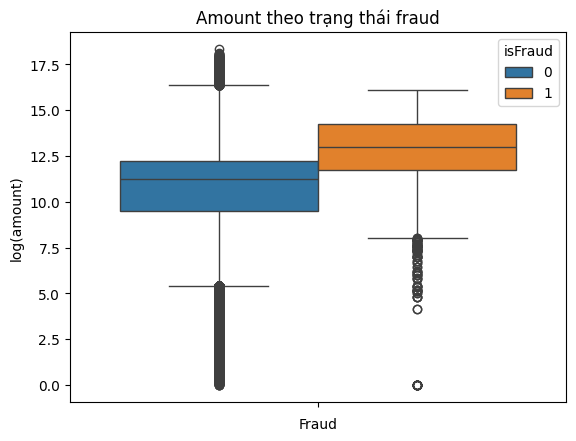

In [39]:
sns.boxplot(y = np.log1p(data['amount']), hue = data['isFraud'])
plt.xlabel('Fraud')
plt.ylabel('log(amount)')
plt.title('Amount theo trạng thái fraud')


Có thể thấy, sau khi biến đổi log đối với feature amount: 
- Nhóm fraud có median ở khoảng 13 (~442k$ đối với giá trị thật), rất ít giá trị dưới 5
- Nhóm non-fraud có median ở khoảng 11 (~60k$ đối với giá trị thật), giá trị trải dài từ 0 - 17.5 

-> Kết luận: 
- Nhóm fraud **có xu hướng giao dịch với giá trị lớn hơn** và **hầu như không có giao dịch dưới giá trị  5 (~148$ giá trị thực)**. 

- Tuy nhiên, phân phối của cả 2 nhóm vẫn còn rất nhiều trùng lặp, vì vậy, **ta không thể phân biệt Fraud chỉ dựa trên giá trị giao dịch (amount)**

##### 📊**Phân tích: Số lượng fraud dựa trên từng loại giao dịch (type)**

Text(0, 0.5, 'số giao dịch fraud')

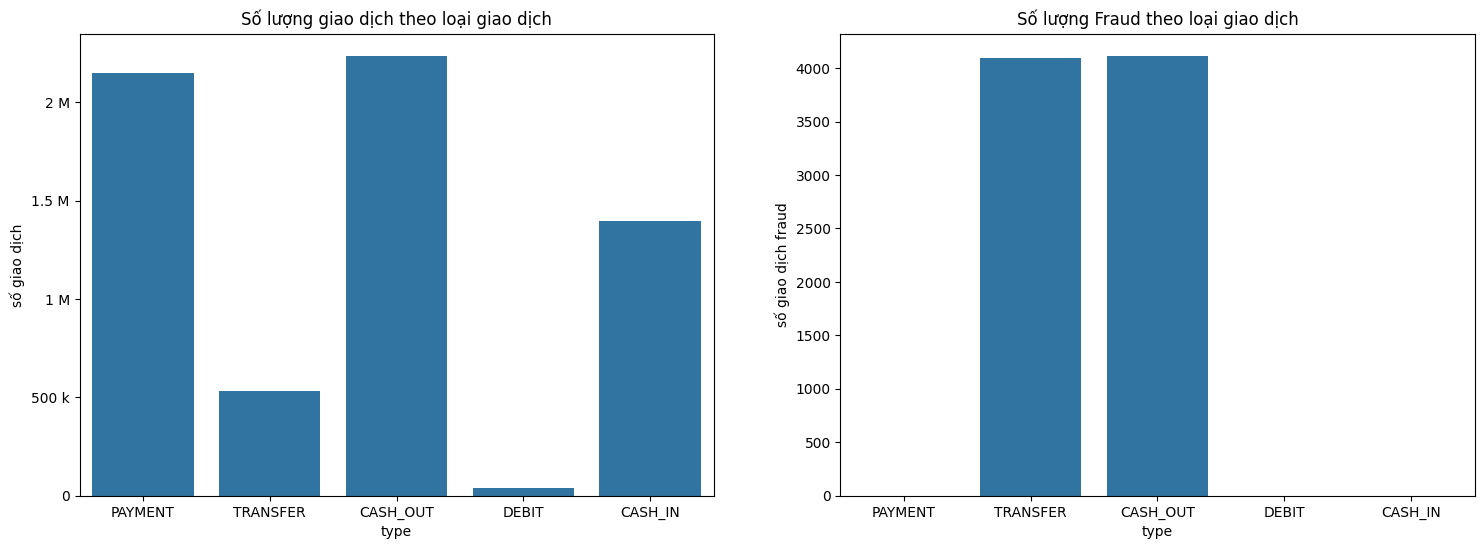

In [40]:
fig, ax = plt.subplots(1,2, figsize = (18,6))
sns.countplot(data = data, x = 'type', ax = ax[0])
ax[0].set_title('Số lượng giao dịch theo loại giao dịch')
ax[0].set_ylabel('số giao dịch')
ax[0].yaxis.set_major_formatter(mticker.EngFormatter())
sns.countplot(data = data[data['isFraud'] == 1], x = 'type', order = data['type'].unique(), ax = ax[1])
ax[1].set_title('Số lượng Fraud theo loại giao dịch')
ax[1].set_ylabel('số giao dịch fraud')


Có thể thấy: 
- Payment và Cash out chiếm phần lớn giao dịch.
- Fraud chỉ xảy ra đối với 2 loại giao dịch **Transfer** và **Cash Out**, với số lượng tương đương nhau.

In [41]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

Kiểm tra fraud rate đối với 2 loại giao dịch Transfer và Cash out:

<Axes: xlabel='type', ylabel='isFraud'>

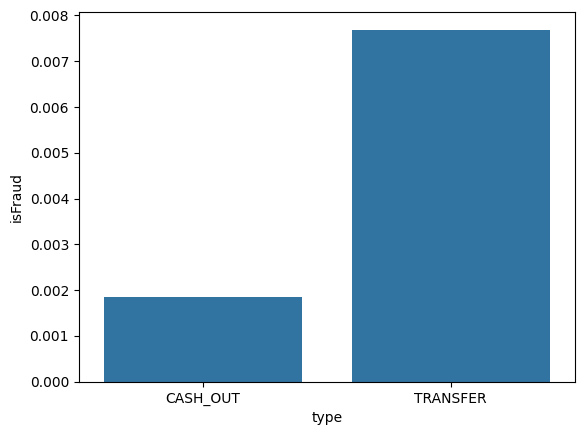

In [42]:
# Tính Fraud rate theo loại giao dịch
fraud_rate_ = data[data['type'].isin(['TRANSFER', 'CASH_OUT'])][['type', 'isFraud']].groupby(['type']).mean().reset_index()
# Vẽ biểu đồ
sns.barplot(data = fraud_rate_, x = 'type', y = 'isFraud')

Có thể thấy **Fraud Rate cao hơn đáng kể đối với loại giao dịch Transfer**, tuy nhiên không vượt quá 1%.

Kiểm tra phân phối của amount dựa theo 2 loại giao dịch đối với giao dịch fraud:

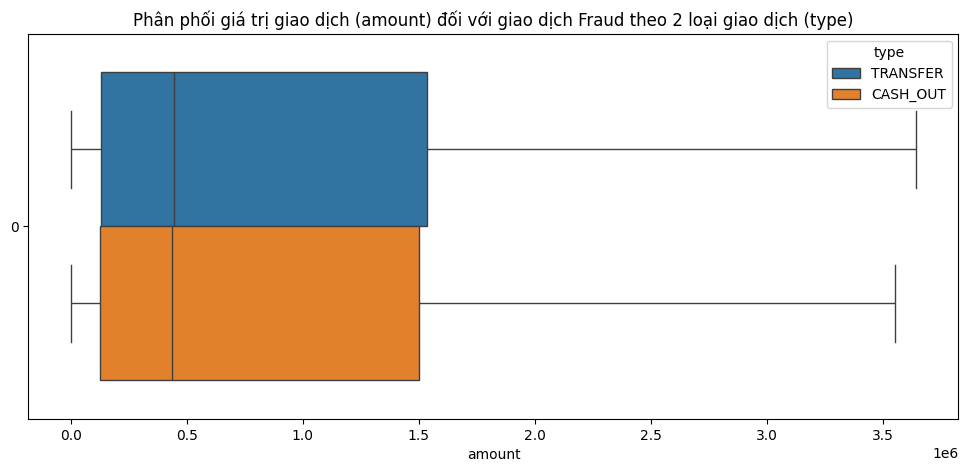

In [43]:
plt.figure(figsize = (12,5))
sns.boxplot(data = data[data['isFraud'] == 1], x = 'amount', hue = 'type', showfliers = False)
plt.title('Phân phối giá trị giao dịch (amount) đối với giao dịch Fraud theo 2 loại giao dịch (type)')
plt.gca().yaxis.set_major_formatter(mticker.EngFormatter())

Có thể thấy: **không có sự khác biệt** trong giá trị giao dịch của các giao dịch lừa đảo đối với 2 loại giao dịch

##### 📊**Phân tích bất thường trong biến động số dư**

In [44]:
# Tạo biến thể hiện hiệu số biến động số dư và amount trong 2 loại tài khoản
error_org = data['oldbalanceOrg'] - data['newbalanceOrig'] - data['amount']
error_dest = data['newbalanceDest'] - data['oldbalanceDest'] - data['amount']

In [45]:
print(f'Số lượng bất thường trong biến động tài khoản gửi: {(~np.isclose(error_org,  0, atol=1e-2)).sum()}')
print(f'Số lượng bất thường trong biến động tài khoản nhận: {(~np.isclose(error_dest,  0, atol=1e-2)).sum()}')

Số lượng bất thường trong biến động tài khoản gửi: 5066425
Số lượng bất thường trong biến động tài khoản nhận: 4122111


Hầu hết các giao dịch đều không có biến động số dư và amount bằng nhau (bất thường), tuy nhiên điều này có thể do số dư trong bộ dữ liệu có thể đã bị ẩn hoặc không được cập nhật đầy đủ, phù hợp với đặc điểm của bộ dữ liệu mô phỏng PaySim.
=> **Không thể sử dụng để phân biệt fraud**


=> Đồng thời, **không thể dùng những biến balance để tạo thêm features**, vì chúng đã bị ẩn và không phản ánh đúng tính chất của giao dịch.

##### 📊**Phân tích theo tài khoản**

In [46]:
data['nameOrig'].value_counts()

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
              ..
C1970706589    1
C40604503      1
C1614818636    1
C2089752665    1
C154988899     1
Name: count, Length: 6353307, dtype: int64

In [47]:
data['nameDest'].value_counts()

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
C1049862186      1
C2118381511      1
C2099952089      1
C1027984317      1
C1251365829      1
Name: count, Length: 2722362, dtype: int64

-> tài khoản gửi (origin) giao dịch tối đa 3 lần, trong khi tài khoản nhận (destination) lặp lại đến 113 lần

Kiểm tra mối quan hệ giữa số lần giao dịch và tình trạng Fraud của **tài khoản gửi (origin)**:

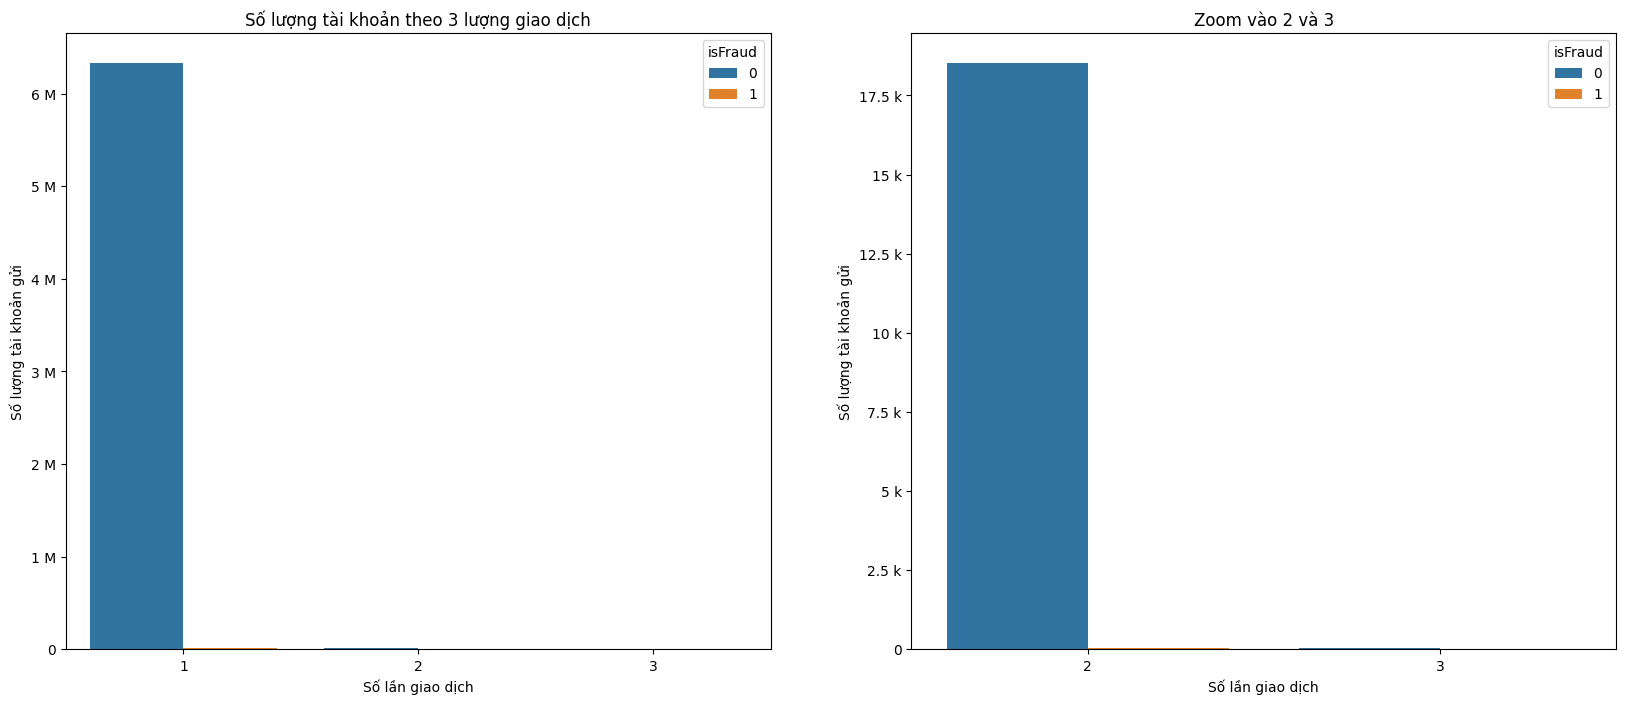

In [48]:

transactions_orig = pd.merge(data, pd.DataFrame(data['nameOrig'].value_counts()).reset_index(), on = 'nameOrig', how = 'left') 
fig, ax = plt.subplots(1,2, figsize = (20,8))
sns.countplot(data = transactions_orig, x = 'count', hue = 'isFraud', order = transactions_orig['count'].unique(), ax = ax[0]  )
ax[0].set_xlabel('Số lần giao dịch')
ax[0].set_ylabel('Số lượng tài khoản gửi')
ax[0].set_title('Số lượng tài khoản theo 3 lượng giao dịch')
ax[0].yaxis.set_major_formatter(mticker.EngFormatter())
sns.countplot(data = transactions_orig[transactions_orig['count'].isin([2,3])], x = 'count', hue = 'isFraud', ax = ax[1]  )
ax[1].set_xlabel('Số lần giao dịch')
ax[1].set_ylabel('Số lượng tài khoản gửi')
ax[1].set_title('Zoom vào 2 và 3')
ax[1].yaxis.set_major_formatter(mticker.EngFormatter())

- Hầu hêt tài khoản gửi đều thực hiện 1 lần giao dịch
- Số lượng fraud nhiều hơn ở 1 lần giao dịch, tuy nhiên có thể giải thích được bằng tỉ lệ (2 và 3 có rất ít tài khoản)

-> **Khó có thể xác định Fraud dựa vào số lần giao dịch của tài khoản gửi**

Kiểm tra mối quan hệ giữa số lần giao dịch và tình trạng fraud ở **tài khoản nhận (destination)**: 

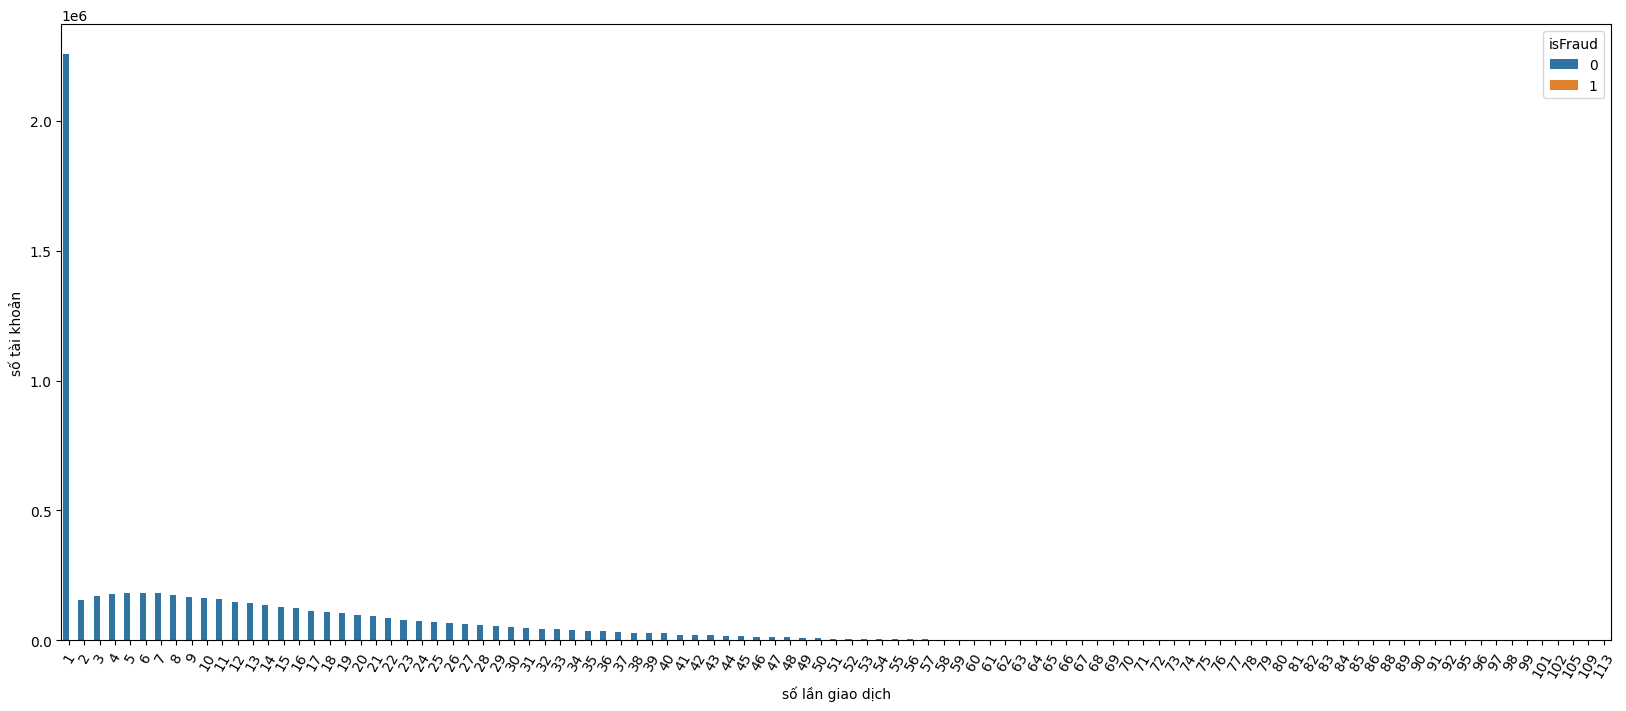

In [49]:

transactions_dest = pd.merge(data, pd.DataFrame(data['nameDest'].value_counts()).reset_index(), on = 'nameDest', how = 'left')
plt.figure(figsize = (20,8)) 
sns.countplot(data = transactions_dest, x = 'count', hue = 'isFraud')
plt.xlabel('số lần giao dịch')
plt.ylabel('số tài khoản')
plt.xticks(rotation = 60)
plt.show()

Tương tự, có thể thấy: 
- Hầu hết tài khoản đều thực hiện 1 lần giao dịch
- Không có sự khác biệt lớn về tỉ lệ Fraud giữa các nhóm khác nhau

-> **Khó có thể xác định Fraud dựa vào số lần giao dịch của tài khoản nhận** 

##### 📊**Phân tích: Fraud theo thời gian (step)**

In [50]:
data['step'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

- Với mỗi step là một giờ, ta có thể thấy bộ dữ liệu bao gồm **~31 ngày**

Số lượng Fraud theo thời gian:

In [51]:

fraud_step = data[data['isFraud'] == 1][['step', 'isFraud']].groupby(['step']).count().reset_index()
fraud_step


,step,isFraud
0,1,16
1,2,8
2,3,4
3,4,10
4,5,6
...,...,...
736,739,10
737,740,6
738,741,22
739,742,14


<Axes: xlabel='step', ylabel='isFraud'>

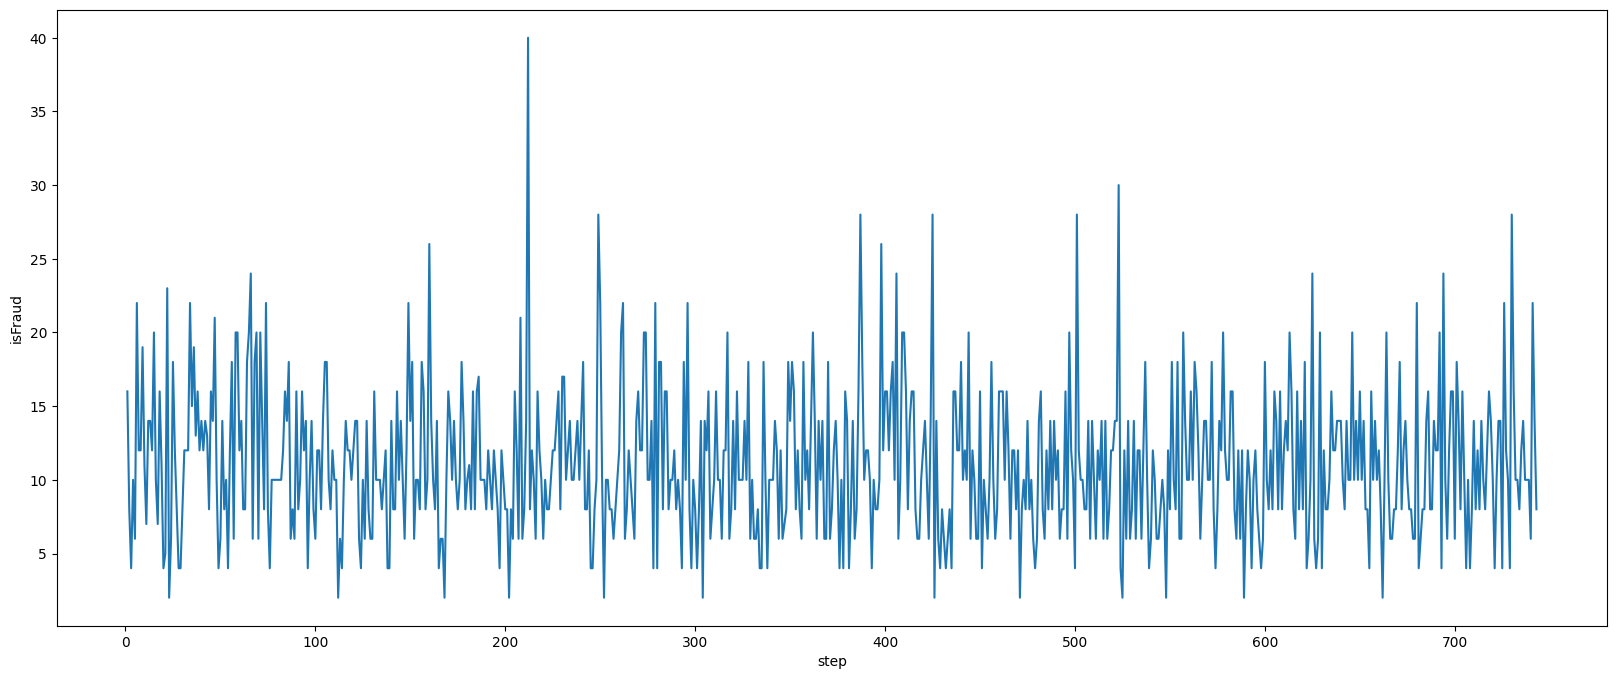

In [52]:
plt.figure(figsize = (20,8))
sns.lineplot(data = fraud_step, x  = 'step', y = 'isFraud')

- Số lượng giao dịch Fraud **có tính mùa vụ theo step**, phân bổ khá đều thông qua quãng thời gian ~750 steps
- Tuy nhiên, số lượng giao dịch fraud còn **phụ thuộc vào số lượng giao dịch** diễn ra trong khung giờ, vì vậy cần kiểm tra **Tổng số lượng giao dịch, Fraud count và fraud rate** trong các khung giờ. 

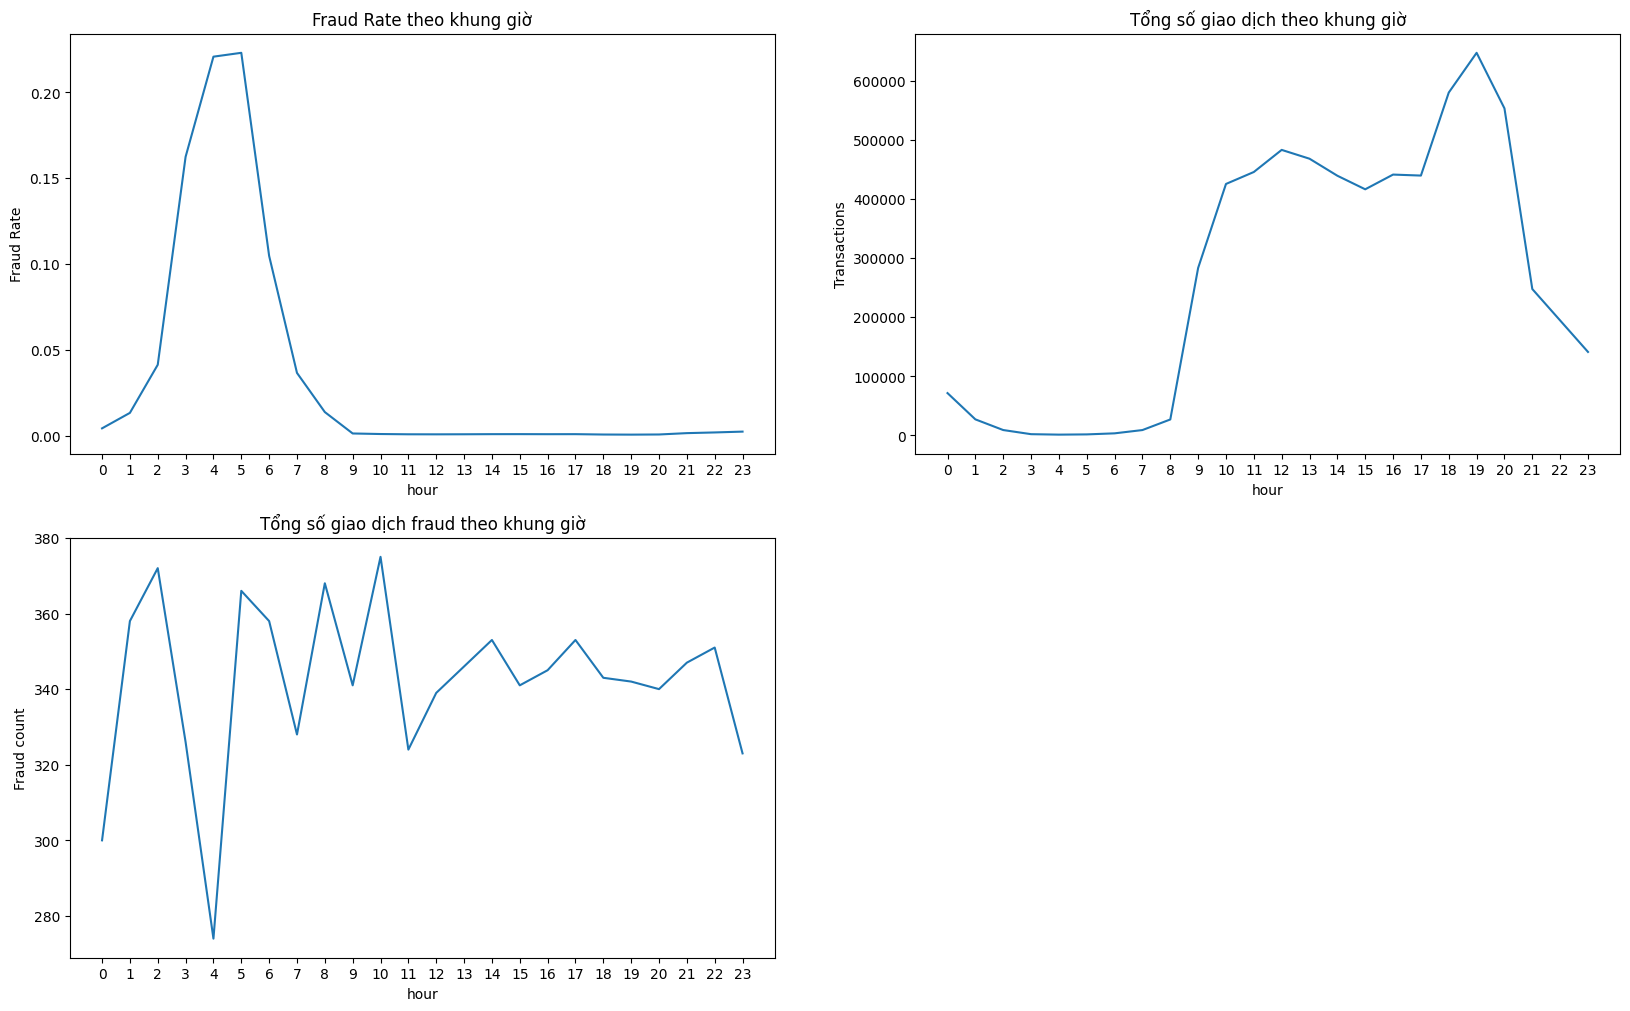

In [53]:
# Tạo biến khung giờ
hour = data.copy()
hour['hour'] = hour['step']%24
#Tính tổng số giao dịch và fraud rate cho từng khung giờ
total = hour[['hour', 'isFraud']].groupby(['hour']).count().reset_index()
fraud_count = hour[['hour', 'isFraud']].groupby(['hour']).sum().reset_index()
fraud_rate = hour[['hour', 'isFraud']].groupby(['hour']).mean().reset_index()
# Tạo biểu đồ 
fig, ax = plt.subplots(2,2, figsize = (20,12))
sns.lineplot(data = fraud_rate, x = 'hour', y ='isFraud', ax = ax[0,0])
ax[0,0].set_xticks(range(24))
ax[0,0].set_title('Fraud Rate theo khung giờ')
ax[0,0].set_ylabel('Fraud Rate')
sns.lineplot(data = total, x = 'hour', y = 'isFraud', ax = ax[0,1])
ax[0,1].set_xticks(range(24))
ax[0,1].set_ylabel('Transactions')
ax[0,1].set_title('Tổng số giao dịch theo khung giờ')
sns.lineplot(data = fraud_count, x = 'hour', y = 'isFraud', ax = ax[1,0])
ax[1,0].set_xticks(range(24))
ax[1,0].set_ylabel('Fraud count')
ax[1,0].set_title('Tổng số giao dịch fraud theo khung giờ')
fig.delaxes(ax[1,1])


Có thể thấy: 
- Vào khung giờ 4h - 5h, Fraud rate tăng đáng kể  tuy nhiên, cả tổng lượng giao dịch và tổng lượng giao dịch lừa đảo đều rất thấp. 

- Ngoài khung giờ này, có thể thấy lượng giao dịch fraud vẫn khá ổn định, giao động trong khoảng 300 - 380 bất chấp sự tăng/giảm đáng kể trong tổng số giao dịch

=> Kết luận: 
- Rủi ro fraud trong khung **4h - 5h tương đối cao** 

- Số lượng giao dịch có **biến động nhẹ theo từng khung giờ** 

- Bất chấp tổng số giao dịch tăng hay giảm, **Fraud count vẫn duy trì ở mức 280 - 380**, cho thấy những **nhóm lừa đảo có xu hướng duy trì mức hoạt động tương đối ổn định bất chấp thời gian giao dịch**

->  Dù sự biến động là chưa đáng kể, ta có thể **tạo thêm feature thể hiện khung giờ** trong feature engineering để giúp tăng khả năng dự đoán của mô hình ML.

#### **3.3. Phân tích tương quan**

<Axes: >

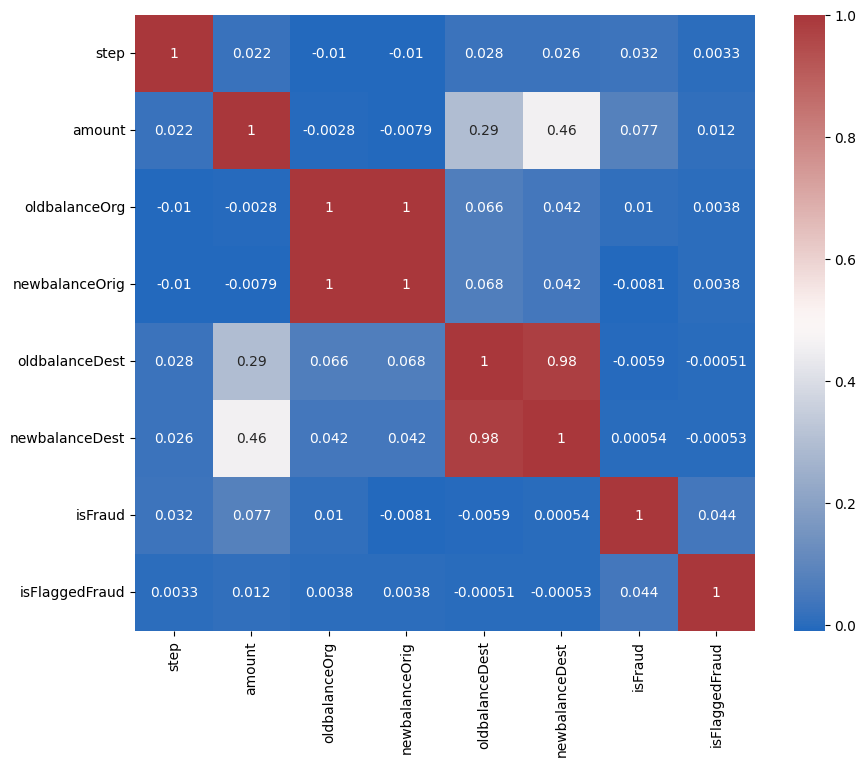

In [54]:
plt.figure(figsize = (10,8))
sns.heatmap(data = data.corr(numeric_only = True), annot = True, cmap = 'vlag')

- Biến isFraud: **Không có tương quan mạnh với các biến khác, gợi ý rằng mối quan hệ có thể là phi tuyến**

- Các biến balance có tương quan lớn theo đôi và tương quan lớn với amount, do chúng đều thể hiện thay đổi số dư 

### **4. Tổng hợp Insights**

##### **4.1. Mất cân bằng dữ liệu nghiêm trọng**

- Biến mục tiêu isFraud có sự mất cân bằng rất lớn giữa hai class: giao dịch Fraud chỉ chiếm khoảng 0.13% tổng số quan sát, trong khi 99.87% là giao dịch Non-fraud

    → Do đó, trước khi huấn luyện mô hình cần **áp dụng các kỹ thuật xử lý class imbalance** như resampling hoặc điều chỉnh class weights.


##### **4.2. Giao dịch gian lận có xu hướng giá trị lớn hơn**
- So sánh giữa hai nhóm:
    - Fraud transactions có (median) **giá trị giao dịch (amount) cao hơn đáng kể** so với non-fraud.
    - Các giao dịch fraud hiếm khi có giá trị nhỏ.
    
    → Tuy nhiên, phân phối của hai nhóm vẫn trùng nhau khá nhiều, do đó amount không đủ để phân biệt fraud một cách độc lập.


##### **4.3. Fraud chỉ xuất hiện ở một số loại giao dịch**
- Fraud chỉ xuất hiện ở một số loại giao dịch
- Fraud chỉ xảy ra ở hai loại giao dịch:
    - TRANSFER
    - CASH_OUT
- Trong đó, **TRANSFER có fraud rate cao hơn so với CASH_OUT**.

→ Điều này cho thấy transaction type là một feature quan trọng trong mô hình dự đoán gian lận.


##### **4.4. Các biến số dư tài khoản không khớp với nhau**

- Phân tích biến động số dư cho thấy phần lớn các giao dịch không thỏa mãn điều kiện cân bằng số dư:
oldbalance − newbalance ≠ amount
- Điều này cho thấy dữ liệu số dư có thể đã bị ẩn hoặc biến đổi, phù hợp với đặc điểm của bộ dữ liệu mô phỏng PaySim.

→ Vì vậy, **không nên tạo feature mới dựa trên balance variables**.


##### **4.5. Fraud có xu hướng xảy ra nhiều hơn vào một số khung giờ**

- Khi phân tích theo thời gian:
    - Fraud rate tăng nhẹ vào khoảng 4h – 5h sáng
    - Tuy nhiên tổng số giao dịch trong khung giờ này khá thấp
- Ngoài ra, Fraud count duy trì khá ổn định (~280 – 380 giao dịch) bất chấp sự biến động của tổng số giao dịch

→ Điều này cho thấy các **nhóm gian lận hoạt động tương đối ổn định theo thời gian**.

→ Tuy nhiên, ta có thể tạo thêm **feature hour of transaction để hỗ trợ mô hình**.


##### **4.6. Tương quan tuyến tính giữa các biến khá yếu**
- Phân tích ma trận tương quan cho thấy: isFraud **không có tương quan tuyến tính mạnh với các biến khác**

→ Điều này gợi ý rằng mối quan hệ giữa fraud và các biến có thể là phi tuyến, do đó các mô hình như:
- Random Forest
- Gradient Boosting
- XGBoost
    
có thể phù hợp hơn so với mô hình tuyến tính như logistic regression.

